<a href="https://colab.research.google.com/github/Palash0306/credit-risk-scoring-engine/blob/develop/notebooks/05_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install boto3 pandas numpy scikit-learn xgboost lightgbm \
             dagshub mlflow pyarrow matplotlib seaborn -q

from google.colab import userdata
import os, boto3, io, json, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dagshub
import mlflow

os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
BUCKET = userdata.get('S3_BUCKET')

# Connect DagsHub MLflow — validation metrics logged as a separate run
dagshub.init(
    repo_owner='Palash0306',
    repo_name='credit-risk-scoring-engine',
    mlflow=True
)

s3 = boto3.client('s3')
print("Setup complete ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=df53adc6-d954-4039-bff8-402671b26e74&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b0d2be6774cc8c9133d0e045186483eae65d9472d6b5535d7f2faf6595e877e9




Accessing as Palash0306

Initialized MLflow to track repo "Palash0306/credit-risk-scoring-engine"

Repository Palash0306/credit-risk-scoring-engine initialized!

Setup complete ✅


In [2]:
# Load best model from S3
print("Loading best model from S3...")
obj_model = s3.get_object(Bucket=BUCKET, Key='models/best_model.pkl')
best_model = pickle.loads(obj_model['Body'].read())

# Load model metadata to know which model we're validating
obj_meta = s3.get_object(Bucket=BUCKET, Key='models/model_metadata.json')
metadata = json.loads(obj_meta['Body'].read())
print(f"Model      : {metadata['model_name']}")
print(f"Train Gini : {metadata['test_gini']:.4f}")

# Load feature table
obj_data = s3.get_object(Bucket=BUCKET, Key='processed/fct_loans.parquet')
df = pd.read_parquet(io.BytesIO(obj_data['Body'].read()))

# Load feature config
obj_cfg = s3.get_object(Bucket=BUCKET, Key='processed/feature_config.json')
config = json.loads(obj_cfg['Body'].read())
SELECTED = config['selected_features']

# Split train/test
df_train = df[df['is_train'] == True].copy()
df_test  = df[df['is_train'] == False].copy()

X_train, y_train = df_train[SELECTED], df_train['default_flag']
X_test,  y_test  = df_test[SELECTED],  df_test['default_flag']

# Get predicted probabilities
proba_train = best_model.predict_proba(X_train)[:, 1]
proba_test  = best_model.predict_proba(X_test)[:, 1]

print(f"Data loaded — Train: {len(X_train):,} | Test: {len(X_test):,} ✅")

Loading best model from S3...
Model      : XGBoost
Train Gini : 0.4201
Data loaded — Train: 826,602 | Test: 518,334 ✅


In [3]:
from sklearn.metrics import roc_auc_score, brier_score_loss

def gini_coefficient(y_true, y_pred_proba):
    """
    Gini = 2 * AUC - 1
    Primary credit model metric.
    > 0.40 = acceptable for production
    > 0.60 = strong model
    """
    return 2 * roc_auc_score(y_true, y_pred_proba) - 1

def ks_statistic(y_true, y_pred_proba):
    """
    KS = max separation between cumulative default
    and non-default score distributions.
    > 0.30 = acceptable for production
    """
    df_ks = pd.DataFrame({'y': y_true, 'p': y_pred_proba})
    df_ks = df_ks.sort_values('p', ascending=False).reset_index(drop=True)
    total_d  = y_true.sum()
    total_nd = len(y_true) - total_d
    df_ks['cum_d']  = (df_ks['y'] == 1).cumsum() / total_d
    df_ks['cum_nd'] = (df_ks['y'] == 0).cumsum() / total_nd
    return (df_ks['cum_d'] - df_ks['cum_nd']).abs().max()

def psi(expected, actual, bins=10):
    """
    Population Stability Index — measures how much the score
    distribution has shifted between train and test.
    < 0.10 = stable (no significant shift)
    0.10-0.25 = moderate shift — investigate
    > 0.25 = major shift — model may be unstable
    """
    # Create bins from expected (train) distribution
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    def psi_bin(exp_pct, act_pct, eps=1e-10):
        return (act_pct - exp_pct) * np.log((act_pct + eps) / (exp_pct + eps))

    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual,   bins=breakpoints)[0]

    exp_pct = exp_counts / len(expected)
    act_pct = act_counts / len(actual)

    return sum(psi_bin(e, a) for e, a in zip(exp_pct, act_pct))

print("Metric functions ready ✅")

Metric functions ready ✅


In [4]:
# ── Gini check — two cases ────────────────────────────────────
gini_test = gini_coefficient(y_test, proba_test)
ks_test   = ks_statistic(y_test, proba_test)
auc_test  = roc_auc_score(y_test, proba_test)
brier     = brier_score_loss(y_test, proba_test)
psi_score = psi(proba_train, proba_test)

print("=" * 50)
print(f"Model: {metadata['model_name']}")
print("=" * 50)
print(f"AUC-ROC      : {auc_test:.4f}  (target > 0.70)")
print(f"Gini         : {gini_test:.4f}  (target > 0.40)")
print(f"KS Statistic : {ks_test:.4f}  (target > 0.30)")
print(f"Brier Score  : {brier:.4f}  (target < 0.15)")
print(f"PSI          : {psi_score:.4f}  (target < 0.10)")
print("=" * 50)

# ── Case A: Gini >= 0.40 — proceed to production ──────────────
if gini_test >= 0.40:
    print(f"\n✅ Gini {gini_test:.4f} >= 0.40 — model meets production threshold")
    print("Proceeding to scorecard conversion and stress test")
    PROCEED = True

# ── Case B: Gini < 0.40 — tune before proceeding ─────────────
else:
    print(f"\n⚠️  Gini {gini_test:.4f} < 0.40 — below production threshold")
    print("Tuning required — see Cell 5 for hyperparameter tuning")
    PROCEED = False

Model: XGBoost
AUC-ROC      : 0.7101  (target > 0.70)
Gini         : 0.4201  (target > 0.40)
KS Statistic : 0.3037  (target > 0.30)
Brier Score  : 0.2053  (target < 0.15)
PSI          : 0.0161  (target < 0.10)

✅ Gini 0.4201 >= 0.40 — model meets production threshold
Proceeding to scorecard conversion and stress test


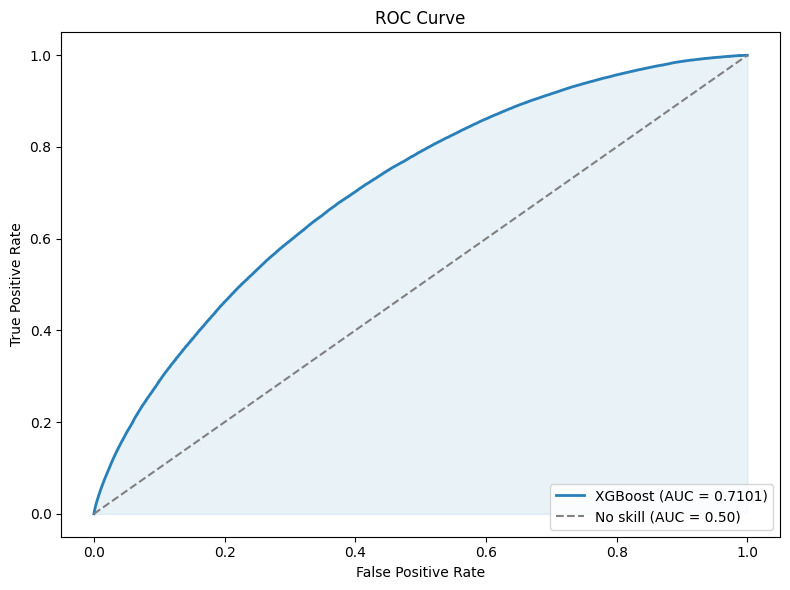

AUC: 0.7101 ✅


In [5]:
from sklearn.metrics import roc_curve

# ROC curve shows tradeoff between true positive rate and false positive rate
# A model with no skill is the diagonal line (AUC = 0.50)
# The further the curve bows to the top-left, the better

fpr, tpr, _ = roc_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2,
        label=f'{metadata["model_name"]} (AUC = {auc_test:.4f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--', label='No skill (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/tmp/roc_curve.png', dpi=150)
plt.show()
print(f"AUC: {auc_test:.4f} ✅")

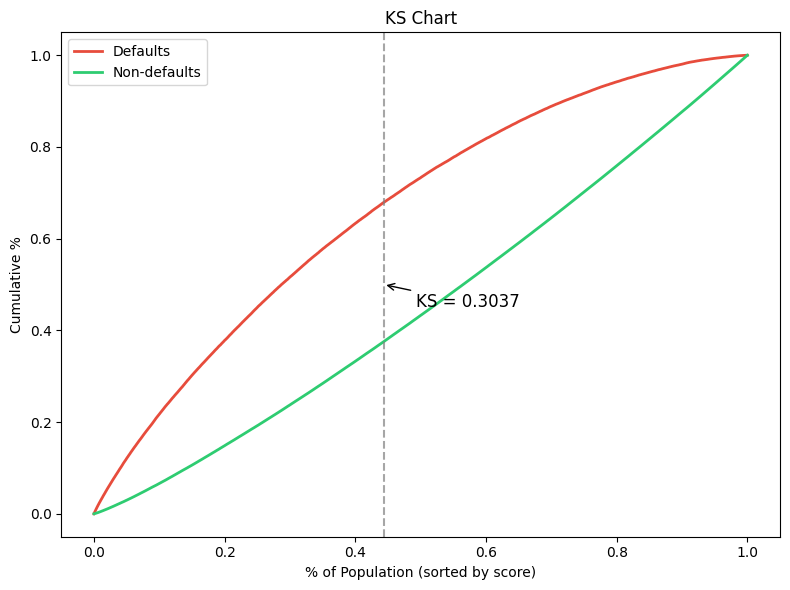

KS Statistic: 0.3037 ✅


In [6]:
# KS chart shows cumulative default and non-default distributions
# The maximum gap between the two curves is the KS statistic
# A higher KS means the model better separates defaulters from non-defaulters

df_ks = pd.DataFrame({'y': y_test.values, 'p': proba_test})
df_ks = df_ks.sort_values('p', ascending=False).reset_index(drop=True)
df_ks['pct_pop']    = (df_ks.index + 1) / len(df_ks)
df_ks['cum_d']      = (df_ks['y'] == 1).cumsum() / y_test.sum()
df_ks['cum_nd']     = (df_ks['y'] == 0).cumsum() / (len(y_test) - y_test.sum())
df_ks['ks_gap']     = (df_ks['cum_d'] - df_ks['cum_nd']).abs()
ks_point            = df_ks.loc[df_ks['ks_gap'].idxmax(), 'pct_pop']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(df_ks['pct_pop'], df_ks['cum_d'],  color='#e74c3c', lw=2, label='Defaults')
ax.plot(df_ks['pct_pop'], df_ks['cum_nd'], color='#2ecc71', lw=2, label='Non-defaults')
ax.axvline(x=ks_point, color='gray', linestyle='--', alpha=0.7)
ax.annotate(f'KS = {ks_test:.4f}',
            xy=(ks_point, 0.5), fontsize=12,
            xytext=(ks_point + 0.05, 0.45),
            arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('% of Population (sorted by score)')
ax.set_ylabel('Cumulative %')
ax.set_title('KS Chart')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/ks_chart.png', dpi=150)
plt.show()

print(f"KS Statistic: {ks_test:.4f} ✅")

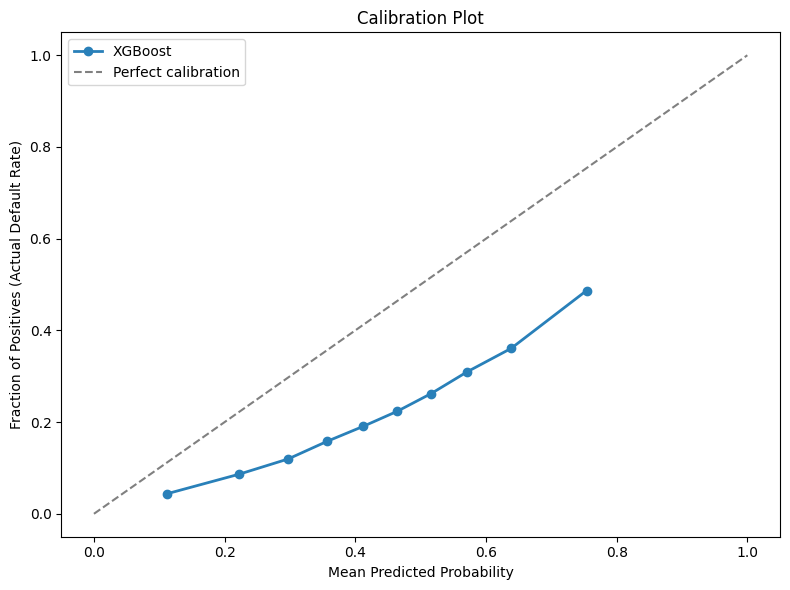

Brier Score: 0.2053 (< 0.15 = good calibration) ✅


In [7]:
from sklearn.calibration import calibration_curve

# Calibration measures whether predicted PD scores are statistically accurate
# If the model predicts PD = 0.15, do 15% of those loans actually default?
# A perfectly calibrated model follows the diagonal line
# Poor calibration = model is systematically over/under-estimating risk

fraction_pos, mean_pred = calibration_curve(
    y_test, proba_test, n_bins=10, strategy='quantile'
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_pred, fraction_pos, 'o-', color='#2980b9', lw=2,
        label=metadata['model_name'])
ax.plot([0,1], [0,1], '--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Actual Default Rate)')
ax.set_title('Calibration Plot')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/calibration.png', dpi=150)
plt.show()
print(f"Brier Score: {brier:.4f} (< 0.15 = good calibration) ✅")

In [8]:
# Log all validation metrics and charts as a dedicated MLflow run
# This creates a clean audit trail — separate from the training runs

with mlflow.start_run(run_name="validation"):
    # Metrics
    mlflow.log_metric("test_auc",   round(auc_test,  4))
    mlflow.log_metric("test_gini",  round(gini_test, 4))
    mlflow.log_metric("test_ks",    round(ks_test,   4))
    mlflow.log_metric("brier_score",round(brier,     4))
    mlflow.log_metric("psi",        round(psi_score, 4))

    # Parameters
    mlflow.log_param("model_name",   metadata['model_name'])
    mlflow.log_param("n_test_rows",  len(y_test))
    mlflow.log_param("test_default_rate", round(y_test.mean(), 4))

    # Artifacts — charts uploaded to MLflow
    mlflow.log_artifact('/tmp/roc_curve.png')
    mlflow.log_artifact('/tmp/ks_chart.png')
    mlflow.log_artifact('/tmp/calibration.png')

    print("Validation metrics logged to MLflow ✅")

# Save validation report to S3
validation_report = {
    'model_name':  metadata['model_name'],
    'test_auc':    round(auc_test,  4),
    'test_gini':   round(gini_test, 4),
    'test_ks':     round(ks_test,   4),
    'brier_score': round(brier,     4),
    'psi':         round(psi_score, 4),
    'meets_production_threshold': bool(gini_test >= 0.40)
}

s3.put_object(
    Bucket=BUCKET,
    Key='models/validation_report.json',
    Body=json.dumps(validation_report, indent=2)
)
print("validation_report.json saved to S3 ✅")

Validation metrics logged to MLflow ✅
🏃 View run validation at: https://dagshub.com/Palash0306/credit-risk-scoring-engine.mlflow/#/experiments/0/runs/f015bb03c1a24f449282772fe2410438
🧪 View experiment at: https://dagshub.com/Palash0306/credit-risk-scoring-engine.mlflow/#/experiments/0
validation_report.json saved to S3 ✅
